In [1]:
import cv2
import faiss
import torch
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms

from pathlib import Path

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [3]:
class ArcFaceResNet50(nn.Module):

    def __init__(self, num_classes=84):

        super().__init__()

        self.backbone = models.resnet50(
            weights=None
        )

        self.backbone.fc = nn.Identity()

        self.embedding = nn.Linear(
            2048,
            512
        )

        self.arcface = nn.Linear(
            512,
            num_classes,
            bias=False
        )

    def forward(self, x):

        x = self.backbone(x)

        x = self.embedding(x)

        x = nn.functional.normalize(
            x,
            p=2,
            dim=1
        )

        return x

In [4]:
model = ArcFaceResNet50(
    num_classes=84
)

model.load_state_dict(
    torch.load(
        "../models/cattle_arcface.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

print("ArcFace model loaded.")

C:\Users\agarw\AppData\Local\Temp\ipykernel_14100\3778834199.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


ArcFace model loaded.


In [5]:
embeddings = np.load(
    "../models/faiss_embeddings.npy"
)

labels = np.load(
    "../models/faiss_labels.npy"
)

print(embeddings.shape)
print(labels.shape)

(838, 512)
(838,)


In [6]:
index = faiss.IndexFlatIP(
    embeddings.shape[1]
)

index.add(
    embeddings.astype(np.float32)
)

print(
    "Vectors in Index:",
    index.ntotal
)

Vectors in Index: 838


In [7]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

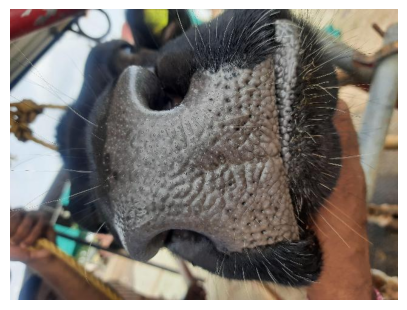

In [8]:
test_image = (
    "../datasets/identity_split/val/"
    "cattle_id_088/"
    "cattle_id_088_01.jpg"
)

img = cv2.imread(test_image)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [9]:
tensor = transform(
    img_rgb
).unsqueeze(0).to(device)

with torch.no_grad():

    embedding = model(
        tensor
    )

embedding = (
    embedding
    .cpu()
    .numpy()
    .astype(np.float32)
)

print(
    embedding.shape
)

(1, 512)


In [10]:
scores, indices = index.search(
    embedding,
    10
)

for rank, (score, idx) in enumerate(
    zip(scores[0], indices[0]),
    start=1
):
    print(
        f"{rank}. "
        f"Label={labels[idx]} "
        f"Score={score:.4f}"
    )

1. Label=9 Score=0.9708
2. Label=9 Score=0.9378
3. Label=9 Score=0.9358
4. Label=9 Score=0.9313
5. Label=9 Score=0.9305
6. Label=9 Score=0.9249
7. Label=9 Score=0.9237
8. Label=9 Score=0.9160
9. Label=9 Score=0.9155
10. Label=9 Score=0.9131


In [11]:
best_score = scores[0][0]
best_label = labels[indices[0][0]]

THRESHOLD = 0.70

if best_score >= THRESHOLD:

    print("Known Cow")
    print("Cow ID:", best_label)
    print("Similarity:", best_score)

else:

    print("Unknown Cow")
    print("Similarity:", best_score)

Known Cow
Cow ID: 9
Similarity: 0.97083735


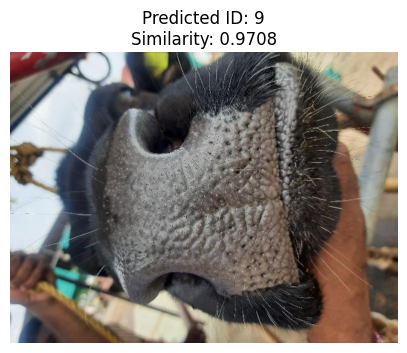

In [12]:
plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.axis("off")

plt.title(
    f"Predicted ID: {best_label}\n"
    f"Similarity: {best_score:.4f}"
)

plt.show()